# IMPORTS

In [ ]:
# 1. Standard library imports
import os

# 2. Third-party imports (Data Science, Visualization, Utilities)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from prettytable import PrettyTable
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# 3. Deep Learning imports (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
from torchvision import models

# DATASET

In [2]:
TRAIN_RATIO = 0.7
TEMP_RATIO = 1 - TRAIN_RATIO
RANDOM_STATE = 42

dataset = pd.read_csv("CSVs/metadata.csv")

assert len(dataset) > 0, "dataset empty, run remove silence first"

# Split 1: train - temp (val + test)
gss_train = GroupShuffleSplit(
    test_size=TEMP_RATIO,
    n_splits=1,
    random_state=RANDOM_STATE
)

train_idx, temp_idx = next(
    gss_train.split(
        dataset,
        groups=dataset["actor"]
    )
)

# Split 2: val - test
temp_subset = dataset.iloc[temp_idx]

gss_val = GroupShuffleSplit(
    test_size=0.5,
    n_splits=1,
    random_state=RANDOM_STATE
)

val_idx, test_idx = next(
    gss_val.split(
        temp_subset,
        groups=temp_subset["actor"]
    )
)

train_df = dataset.iloc[train_idx].reset_index(drop=True)
val_df = temp_subset.iloc[val_idx].reset_index(drop=True)
test_df = temp_subset.iloc[test_idx].reset_index(drop=True)

print(f"Train : {len(train_df):>5} samples ({len(train_df) / len(dataset) * 100:.1f}%) - Actors: {len(set(train_df['actor']))}")
print(f"Val   : {len(val_df):>5} samples ({len(val_df) / len(dataset) * 100:.1f}%) - Actors: {len(set(val_df['actor']))}")
print(f"Test  : {len(test_df):>5} samples ({len(test_df) / len(dataset) * 100:.1f}%) - Actors: {len(set(test_df['actor']))}")

def create_csv(df, path):
    df.to_csv(path, index=False)
    
os.makedirs("CSVs", exist_ok=True)

create_csv(train_df, "CSVs/train.csv")
create_csv(val_df, "CSVs/val.csv")
create_csv(test_df, "CSVs/test.csv")

# Check for actor overlap (LEAK)

train_actors = set(train_df["actor"])
val_actors   = set(val_df["actor"])
test_actors  = set(test_df["actor"])

assert train_actors.isdisjoint(val_actors),  "LEAK: actor xuất hiện ở cả train lẫn val!"
assert train_actors.isdisjoint(test_actors), "LEAK: actor xuất hiện ở cả train lẫn test!"
assert val_actors.isdisjoint(test_actors),   "LEAK: actor xuất hiện ở cả val lẫn test!"
print("\nNo actor overlap between splits. Data leakage check passed!")

Train :   960 samples (66.7%) - Actors: 16
Val   :   240 samples (16.7%) - Actors: 4
Test  :   240 samples (16.7%) - Actors: 4

No actor overlap between splits. Data leakage check passed!


# DATA LOADER

In [3]:
# ── Label map ──────────────────────────────────────────────────
EMOTIONS = ["neutral", "calm", "happy", "sad",
            "angry", "fearful", "disgust", "surprised"]
LABEL2IDX = {e: i for i, e in enumerate(EMOTIONS)}

# ── Dataset ────────────────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, csv_path, augment=False):
        self.df      = pd.read_csv(csv_path)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        feat = np.load(row["feat_path"])        # (3, 224, 224) float32
        feat = torch.from_numpy(feat)           # Tensor

        if self.augment:
            feat = self._spec_augment(feat)

        label = LABEL2IDX[row["emotion"]]
        return feat, label

    @staticmethod
    def _spec_augment(feat, F=27, T=50):
        """
        SpecAugment nhẹ — mask dải tần và dải thời gian ngẫu nhiên.
        Áp dụng giống nhau lên cả 3 channel để giữ nhất quán.
        """
        feat = feat.clone()
        _, n_mels, n_frames = feat.shape

        # Frequency masking
        f  = np.random.randint(0, F)
        f0 = np.random.randint(0, n_mels - f)
        feat[:, f0:f0 + f, :] = 0

        # Time masking
        t  = np.random.randint(0, T)
        t0 = np.random.randint(0, n_frames - t)
        feat[:, :, t0:t0 + t] = 0

        return feat


# ── DataLoader ─────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 0

train_ds = EmotionDataset("CSVs/train.csv", augment=True)
val_ds   = EmotionDataset("CSVs/val.csv",   augment=False)
test_ds  = EmotionDataset("CSVs/test.csv",  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


# ── Sanity check ───────────────────────────────────────────────
feats, labels = next(iter(train_loader))

print(f"Batch feats  : {feats.shape}")   # (32, 3, 224, 224)
print(f"Batch labels : {labels.shape}")  # (32,)
print(f"Feat dtype   : {feats.dtype}")   # torch.float32
print(f"Label range  : {labels.min()} – {labels.max()}")
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Batch feats  : torch.Size([32, 3, 224, 224])
Batch labels : torch.Size([32])
Feat dtype   : torch.float32
Label range  : 0 – 7

Train batches : 30
Val   batches : 8
Test  batches : 8


# MODEL

## ResNet

In [4]:
class BuildResnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False
        for layer in [self.model.layer4]:
            for param in layer.parameters():
                param.requires_grad = True

        self.model.fc = nn.Sequential( # type: ignore
            nn.Linear(self.model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)

## DenseNet

In [5]:
class BuildDenseNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        self.model.classifier = nn.Sequential( # type: ignore
            nn.Linear(self.model.classifier.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)

## VGG

In [6]:
class BuildVGG16(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        self.model.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)

## BUILD ALL

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = len(EMOTIONS)

def build_all(num_classes=NUM_CLASSES):
    resnet   = BuildResnet(num_classes).to(device)
    densenet = BuildDenseNet(num_classes).to(device)
    vgg      = BuildVGG16(num_classes).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizers = {
        "ResNet18": optim.AdamW([
            # {"params": resnet.model.layer3.parameters(),  "lr": 5e-6},
            {"params": resnet.model.layer4.parameters(),  "lr": 1e-5},
            {"params": resnet.model.fc.parameters(),      "lr": 1e-3},
        ], weight_decay=1e-3),

        "DenseNet121": optim.AdamW(
            filter(lambda p: p.requires_grad, densenet.parameters()),
            lr=1e-3, weight_decay=5e-4,
        ),

        "VGG16": optim.AdamW(
            filter(lambda p: p.requires_grad, vgg.parameters()),
            lr=1e-3, weight_decay=5e-4,
        ),
    }

    schedulers = {
        name: optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=5
        )
        for name, opt in optimizers.items()
    }

    models_dict = {"ResNet18": resnet, "DenseNet121": densenet, "VGG16": vgg}

    # Summary
    print(f"Device: {device}\n")
    for name, model in models_dict.items():
        total     = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"{name:<12} trainable: {trainable:>9,} / {total:>9,} ({trainable/total*100:.1f}%)")

    return models_dict, optimizers, schedulers, criterion


models_dict, optimizers, schedulers, criterion = build_all()

Device: cuda

ResNet18     trainable: 8,527,112 / 11,309,896 (75.4%)
DenseNet121  trainable:   264,456 / 7,218,312 (3.7%)
VGG16        trainable: 6,424,840 / 21,139,528 (30.4%)


# TRAIN / VALIDATE / TEST

## Train & Validate

In [8]:
def train_model(model, optimizer, scheduler, criterion,
                train_loader, val_loader,
                epochs=30, patience=5):

    name = model._get_name()
    save_path = f"{name}.pth"

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "train_recall": [], "train_precision": [],
        "val_loss": [], "val_acc": [], "val_f1": [],
        "val_recall": [], "val_precision": [],
    }

    best_val_loss = float("inf")
    best_epoch    = 0
    counter       = 0

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────
        model.train()
        train_labels_all, train_preds_all = [], []
        running_loss, train_total = 0.0, 0

        for images, labels in tqdm(train_loader,
                desc=f"[{name}] Epoch {epoch+1}/{epochs} - Train", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            bs            = images.size(0)
            running_loss += loss.item() * bs
            train_total  += bs
            preds         = torch.argmax(outputs, dim=1)
            train_labels_all.extend(labels.cpu().numpy())
            train_preds_all.extend(preds.cpu().numpy())

        train_loss      = running_loss / train_total
        train_acc       = accuracy_score(train_labels_all, train_preds_all)
        train_f1        = f1_score(train_labels_all, train_preds_all, average="weighted")
        train_recall    = recall_score(train_labels_all, train_preds_all,
                                       average="weighted", zero_division=0)
        train_precision = precision_score(train_labels_all, train_preds_all,
                                          average="weighted", zero_division=0)

        # ── Validation ─────────────────────────────────────────
        model.eval()
        val_labels_all, val_preds_all = [], []
        val_running_loss, val_total   = 0.0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader,
                    desc=f"[{name}] Epoch {epoch+1}/{epochs} - Val", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss    = criterion(outputs, labels)

                bs               = images.size(0)
                val_running_loss += loss.item() * bs
                val_total        += bs
                preds             = torch.argmax(outputs, dim=1)
                val_labels_all.extend(labels.cpu().numpy())
                val_preds_all.extend(preds.cpu().numpy())

        val_loss      = val_running_loss / val_total
        val_acc       = accuracy_score(val_labels_all, val_preds_all)
        val_f1        = f1_score(val_labels_all, val_preds_all, average="weighted")
        val_recall    = recall_score(val_labels_all, val_preds_all,
                                     average="weighted", zero_division=0)
        val_precision = precision_score(val_labels_all, val_preds_all,
                                        average="weighted", zero_division=0)

        scheduler.step(val_loss)


        # ── Log ────────────────────────────────────────────────
        for k, v in [("train_loss", train_loss), ("train_acc", train_acc),
                     ("train_f1", train_f1), ("train_recall", train_recall),
                     ("train_precision", train_precision), ("val_loss", val_loss),
                     ("val_acc", val_acc), ("val_f1", val_f1),
                     ("val_recall", val_recall), ("val_precision", val_precision)]:
            history[k].append(v)

        lr_str = " | ".join(f"g{i}:{pg['lr']:.1e}"
                            for i, pg in enumerate(optimizer.param_groups))

        table = PrettyTable()
        table.title        = f"[{name}] Epoch {epoch+1}/{epochs}  ({lr_str})"
        table.field_names  = ["Split", "Loss", "Acc", "F1", "Recall", "Precision"]
        table.align        = "r"
        table.float_format = ".4"

        table.add_row(["Train", train_loss, train_acc, train_f1,
                       train_recall, train_precision])
        table.add_row(["Val",   val_loss,   val_acc,   val_f1,
                       val_recall,   val_precision])
        print(table)

        # ── Early stopping & checkpoint ────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch + 1
            counter       = 0
            torch.save(model.state_dict(), save_path)
            print(f"  --> Best model saved (val_loss={best_val_loss:.4f})")
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    # ── Restore best weights ───────────────────────────────────
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    print(f"\n[{name}] Training done. Best epoch: {best_epoch} | "
          f"Best val_loss: {best_val_loss:.4f}")

    return history

### resnet

In [9]:
history_resnet = train_model(
    models_dict["ResNet18"],
    optimizers["ResNet18"],
    schedulers["ResNet18"],
    criterion, train_loader, val_loader,
)

+-------------------------------------------------------+
|  [BuildResnet] Epoch 1/30  (g0:1.0e-05 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.1372 | 0.1365 | 0.1326 | 0.1365 |    0.1326 |
|   Val | 2.0368 | 0.2417 | 0.1584 | 0.2417 |    0.1750 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=2.0368)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 2/30  (g0:1.0e-05 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.0347 | 0.1740 | 0.1620 | 0.1740 |    0.1657 |
|   Val | 1.9788 | 0.2792 | 0.2422 | 0.2792 |    0.3985 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9788)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 3/30  (g0:1.0e-05 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.9845 | 0.2198 | 0.2036 | 0.2198 |    0.2636 |
|   Val | 1.9207 | 0.2583 | 0.1929 | 0.2583 |    0.2707 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9207)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 4/30  (g0:1.0e-05 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.9457 | 0.2510 | 0.2296 | 0.2510 |    0.2273 |
|   Val | 1.8511 | 0.2750 | 0.2118 | 0.2750 |    0.2861 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8511)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 5/30  (g0:1.0e-05 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.8712 | 0.2771 | 0.2511 | 0.2771 |    0.2459 |
|   Val | 1.8118 | 0.3292 | 0.2903 | 0.3292 |    0.3245 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8118)


...

+-------------------------------------------------------+
|  [BuildResnet] Epoch 15/30  (g0:1.0e-05 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5489 | 0.4750 | 0.4590 | 0.4750 |    0.4624 |
|   Val | 1.6977 | 0.3875 | 0.3770 | 0.3875 |    0.4074 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 16/30  (g0:1.0e-05 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5194 | 0.4802 | 0.4592 | 0.4802 |    0.4578 |
|   Val | 1.6980 | 0.4167 | 0.4017 | 0.4167 |    0.4415 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 17/30  (g0:1.0e-05 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5170 | 0.5052 | 0.4872 | 0.5052 |    0.4868 |
|   Val | 1.7300 | 0.3875 | 0.3731 | 0.3875 |    0.4164 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 18/30  (g0:1.0e-05 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.4810 | 0.5240 | 0.5008 | 0.5240 |    0.4970 |
|   Val | 1.7186 | 0.4125 | 0.3983 | 0.4125 |    0.4201 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 19/30  (g0:1.0e-05 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.4997 | 0.5156 | 0.4936 | 0.5156 |    0.4954 |
|   Val | 1.6891 | 0.4083 | 0.3800 | 0.4083 |    0.4322 |
+-------+--------+--------+--------+--------+-----------+
  Early stopping at epoch 19.

[BuildResnet] Training done. Best epoch: 14 | Best val_loss: 1.6718


### densenet

In [10]:
history_densenet = train_model(
    models_dict["DenseNet121"],
    optimizers["DenseNet121"],
    schedulers["DenseNet121"],
    criterion, train_loader, val_loader,
)

+-------------------------------------------------------+
|        [BuildDenseNet] Epoch 1/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.1158 | 0.1427 | 0.1382 | 0.1427 |    0.1413 |
|   Val | 2.0569 | 0.2125 | 0.1336 | 0.2125 |    0.1738 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=2.0569)


+-------------------------------------------------------+
|        [BuildDenseNet] Epoch 2/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.0475 | 0.1802 | 0.1719 | 0.1802 |    0.1711 |
|   Val | 1.9912 | 0.2917 | 0.2291 | 0.2917 |    0.2155 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9912)


+-------------------------------------------------------+
|        [BuildDenseNet] Epoch 3/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.0080 | 0.2125 | 0.2022 | 0.2125 |    0.1971 |
|   Val | 1.9488 | 0.2500 | 0.1576 | 0.2500 |    0.1468 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9488)


+-------------------------------------------------------+
|        [BuildDenseNet] Epoch 4/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.9736 | 0.2365 | 0.2157 | 0.2365 |    0.2206 |
|   Val | 1.9147 | 0.3292 | 0.2576 | 0.3292 |    0.2845 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9147)


+-------------------------------------------------------+
|        [BuildDenseNet] Epoch 5/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.9381 | 0.2792 | 0.2513 | 0.2792 |    0.2509 |
|   Val | 1.8934 | 0.2875 | 0.2396 | 0.2875 |    0.3644 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8934)


...

+-------------------------------------------------------+
|       [BuildDenseNet] Epoch 13/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.8078 | 0.3406 | 0.3193 | 0.3406 |    0.3298 |
|   Val | 1.8270 | 0.3042 | 0.2720 | 0.3042 |    0.3962 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|       [BuildDenseNet] Epoch 14/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7920 | 0.3500 | 0.3322 | 0.3500 |    0.3361 |
|   Val | 1.8108 | 0.3042 | 0.2494 | 0.3042 |    0.3057 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|       [BuildDenseNet] Epoch 15/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7808 | 0.3542 | 0.3476 | 0.3542 |    0.3504 |
|   Val | 1.8124 | 0.3625 | 0.3124 | 0.3625 |    0.3436 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|       [BuildDenseNet] Epoch 16/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7796 | 0.3646 | 0.3421 | 0.3646 |    0.3496 |
|   Val | 1.8321 | 0.3125 | 0.2507 | 0.3125 |    0.3735 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|       [BuildDenseNet] Epoch 17/30  (g0:1.0e-03)       |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7749 | 0.3469 | 0.3313 | 0.3469 |    0.3283 |
|   Val | 1.8373 | 0.3667 | 0.3356 | 0.3667 |    0.4604 |
+-------+--------+--------+--------+--------+-----------+
  Early stopping at epoch 17.

[BuildDenseNet] Training done. Best epoch: 12 | Best val_loss: 1.7898


### vgg

In [11]:
history_vgg = train_model(
    models_dict["VGG16"],
    optimizers["VGG16"],
    schedulers["VGG16"],
    criterion, train_loader, val_loader,
)

+-------------------------------------------------------+
|         [BuildVGG16] Epoch 1/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.1486 | 0.2021 | 0.1902 | 0.2021 |    0.1871 |
|   Val | 1.8229 | 0.3333 | 0.2923 | 0.3333 |    0.3296 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8229)


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 2/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.8467 | 0.3094 | 0.2978 | 0.3094 |    0.3033 |
|   Val | 1.7045 | 0.3583 | 0.3272 | 0.3583 |    0.4582 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.7045)


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 3/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7355 | 0.3865 | 0.3693 | 0.3865 |    0.3926 |
|   Val | 1.6131 | 0.4375 | 0.4203 | 0.4375 |    0.4623 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.6131)


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 4/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6518 | 0.4250 | 0.4091 | 0.4250 |    0.4070 |
|   Val | 1.6295 | 0.4333 | 0.4160 | 0.4333 |    0.4895 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 5/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6090 | 0.4552 | 0.4376 | 0.4552 |    0.4415 |
|   Val | 1.6159 | 0.4667 | 0.4601 | 0.4667 |    0.4727 |
+-------+--------+--------+--------+--------+-----------+


...

+-------------------------------------------------------+
|         [BuildVGG16] Epoch 7/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.4792 | 0.5083 | 0.4998 | 0.5083 |    0.4970 |
|   Val | 1.6549 | 0.4750 | 0.4501 | 0.4750 |    0.5359 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 8/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.4521 | 0.5427 | 0.5329 | 0.5427 |    0.5337 |
|   Val | 1.5705 | 0.4792 | 0.4603 | 0.4792 |    0.5118 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 9/30  (g0:1.0e-03)         |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.4028 | 0.5687 | 0.5604 | 0.5687 |    0.5611 |
|   Val | 1.6356 | 0.4667 | 0.4630 | 0.4667 |    0.5609 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 10/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.3716 | 0.5781 | 0.5736 | 0.5781 |    0.5730 |
|   Val | 1.6390 | 0.4833 | 0.4764 | 0.4833 |    0.5125 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|         [BuildVGG16] Epoch 11/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.3682 | 0.5823 | 0.5748 | 0.5823 |    0.5745 |
|   Val | 1.5713 | 0.4833 | 0.4851 | 0.4833 |    0.5132 |
+-------+--------+--------+--------+--------+-----------+
  Early stopping at epoch 11.

[BuildVGG16] Training done. Best epoch: 6 | Best val_loss: 1.5688


### Plot

In [12]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.suptitle(f"{model_name} — Training History", fontweight="bold")

    metrics = [
        ("Loss",     "train_loss", "val_loss"),
        ("Accuracy", "train_acc",  "val_acc"),
        ("F1 Score", "train_f1",   "val_f1"),
    ]

    for ax, (ylabel, train_key, val_key) in zip(axes, metrics):
        ax.plot(history[train_key], label=f"Train {ylabel}", marker="o", linewidth=2)
        ax.plot(history[val_key],   label=f"Val {ylabel}",   marker="o", linewidth=2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Train vs Val {ylabel}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Test

In [13]:
def evaluate_model(model, loader, model_name, emotions=EMOTIONS):
    model.eval()
    true_all, pred_all = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Evaluating {model_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            true_all.extend(labels.cpu().numpy())
            pred_all.extend(preds.cpu().numpy())

    # Classification report
    print(f"\n[{model_name}] Classification Report (Test):")
    print(classification_report(true_all, pred_all,
                                target_names=emotions, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(true_all, pred_all)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=emotions, yticklabels=emotions)
    plt.title(f"{model_name} — Confusion Matrix (Test)")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return true_all, pred_all

# Result

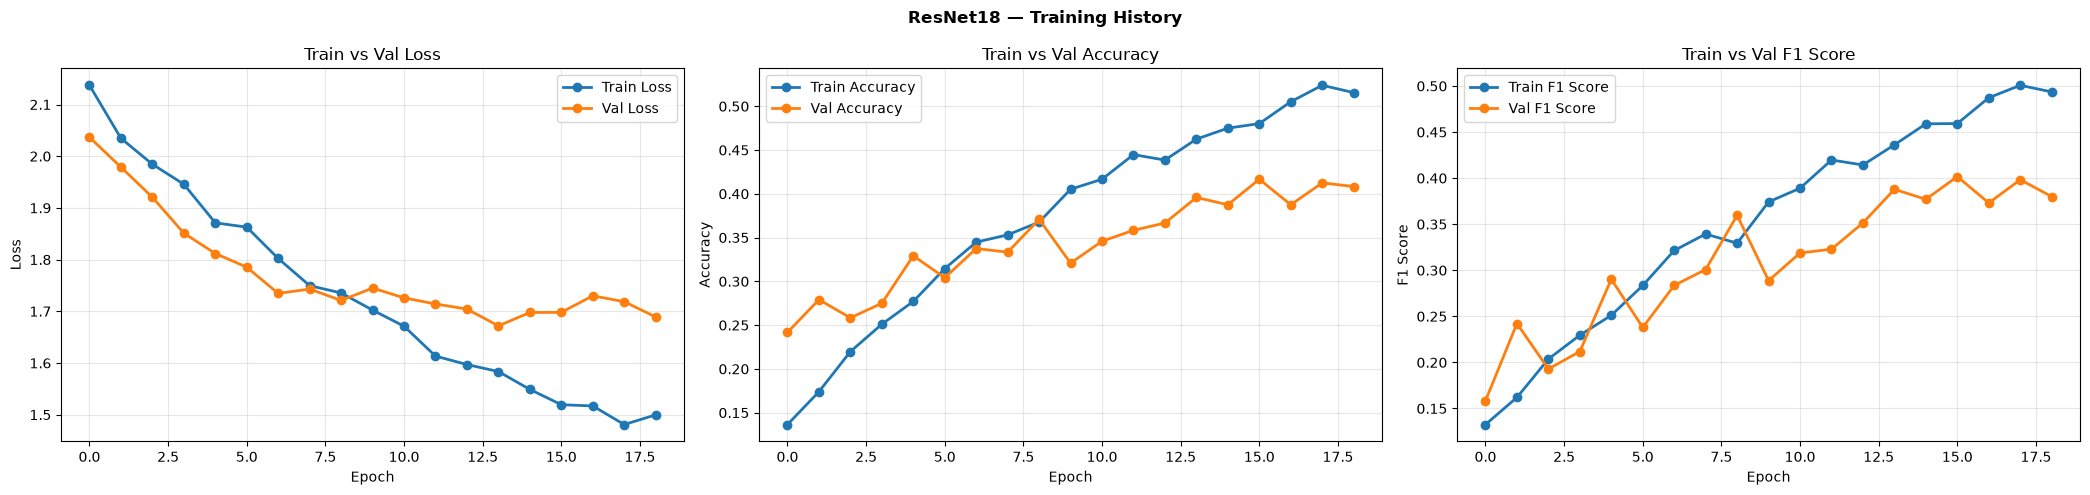


[ResNet18] Classification Report (Test):
              precision    recall  f1-score   support

     neutral       0.50      0.12      0.20        16
        calm       0.65      0.69      0.67        32
       happy       0.28      0.22      0.25        32
         sad       0.35      0.22      0.27        32
       angry       0.40      0.69      0.51        32
     fearful       0.57      0.62      0.60        32
     disgust       0.58      0.44      0.50        32
   surprised       0.51      0.69      0.59        32

    accuracy                           0.48       240
   macro avg       0.48      0.46      0.45       240
weighted avg       0.48      0.48      0.46       240



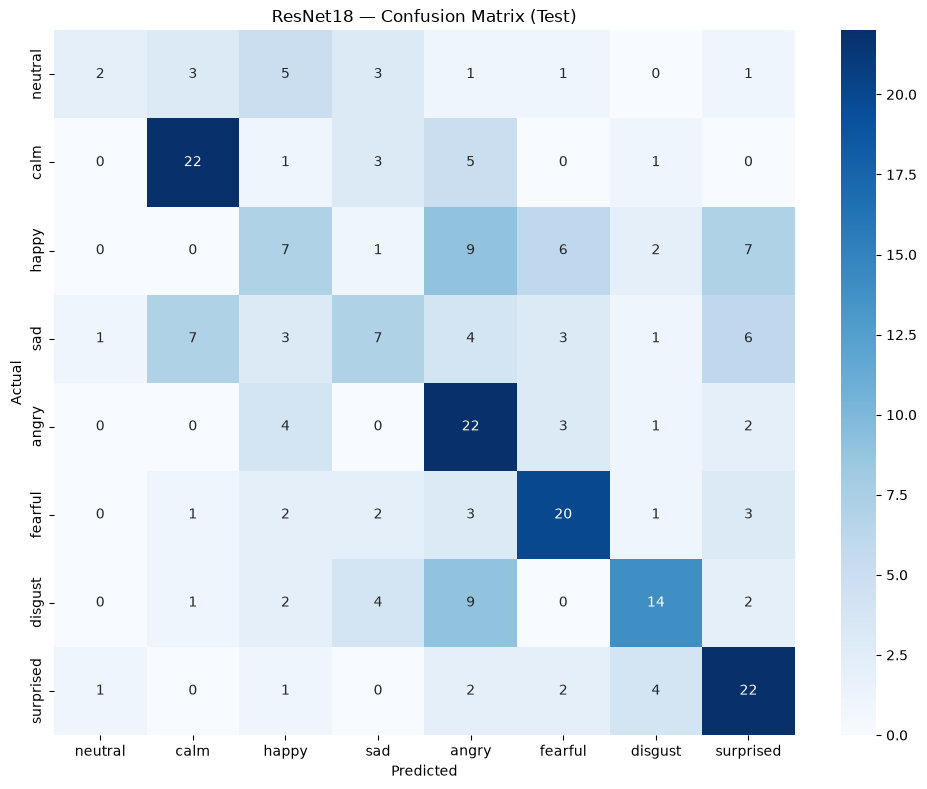

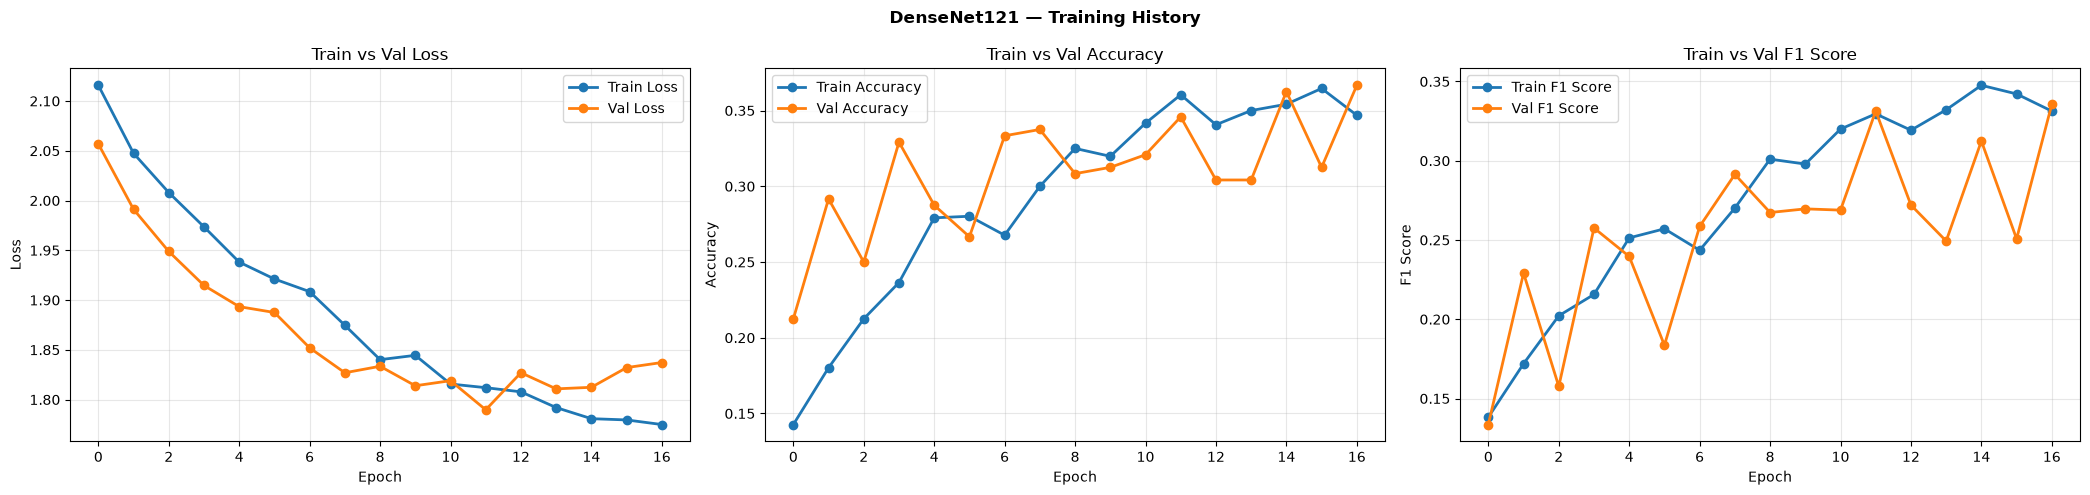


[DenseNet121] Classification Report (Test):
              precision    recall  f1-score   support

     neutral       0.80      0.25      0.38        16
        calm       0.65      0.53      0.59        32
       happy       0.00      0.00      0.00        32
         sad       0.31      0.16      0.21        32
       angry       0.29      0.72      0.42        32
     fearful       0.62      0.56      0.59        32
     disgust       0.37      0.44      0.40        32
   surprised       0.41      0.56      0.47        32

    accuracy                           0.41       240
   macro avg       0.43      0.40      0.38       240
weighted avg       0.41      0.41      0.38       240



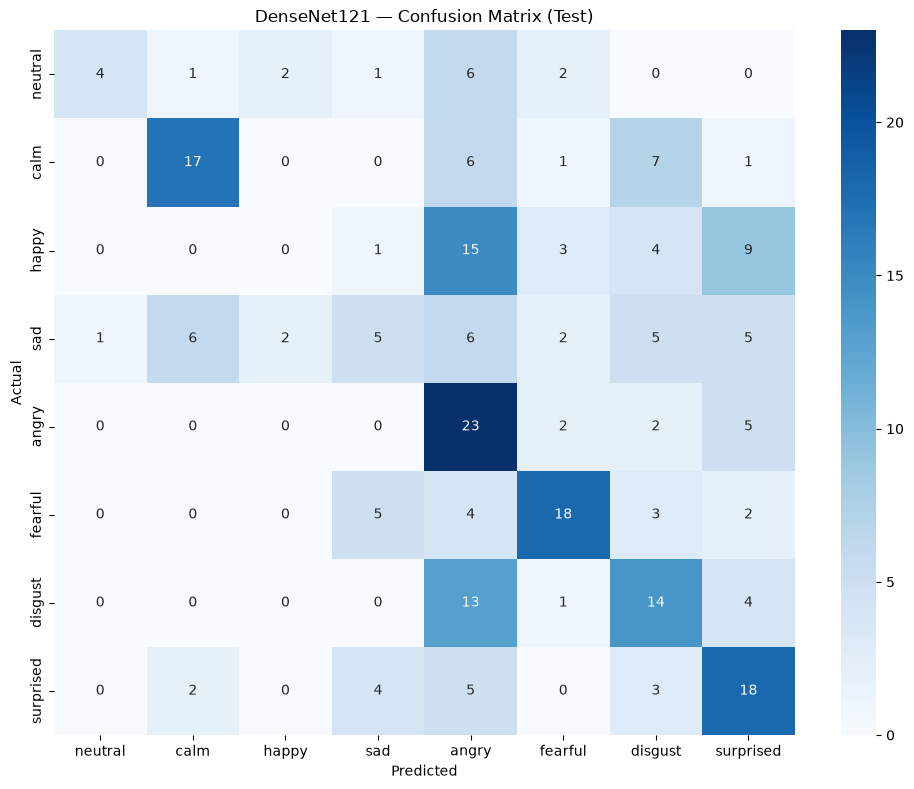

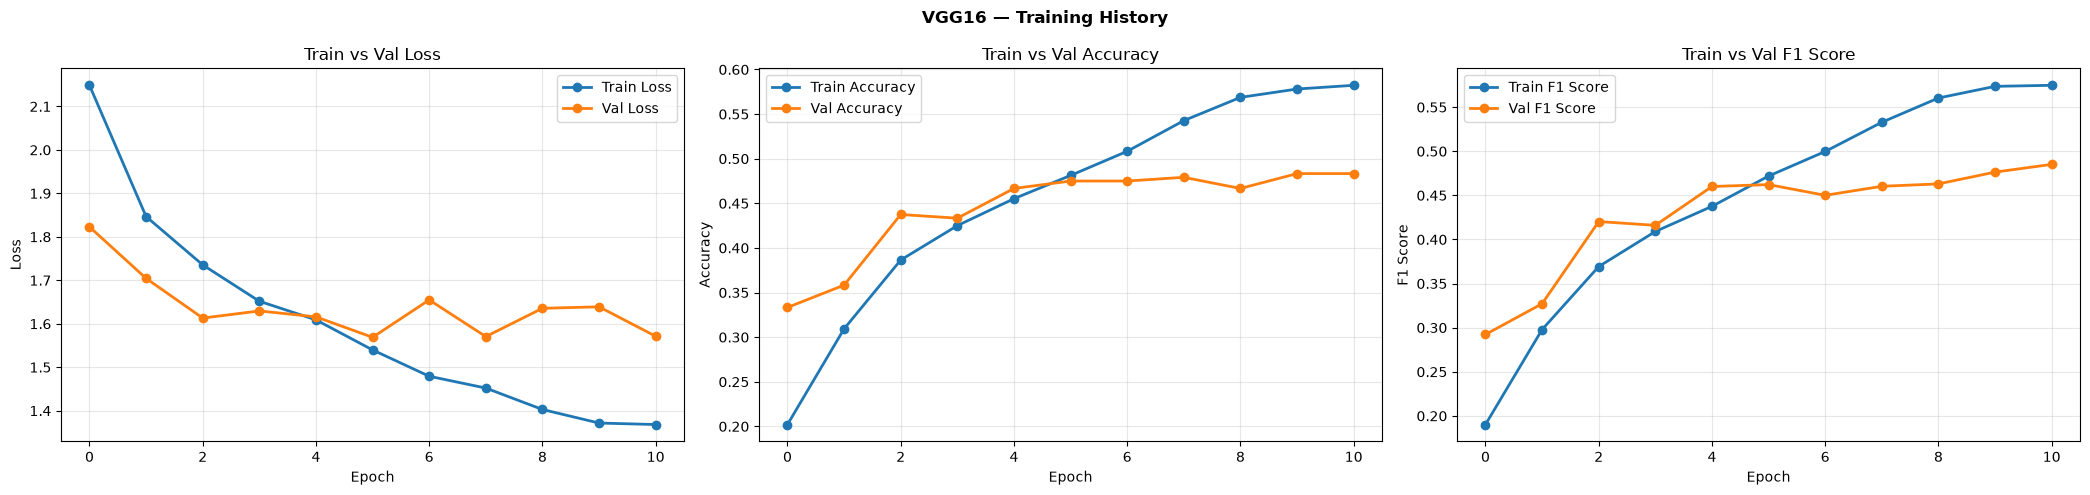


[VGG16] Classification Report (Test):
              precision    recall  f1-score   support

     neutral       0.38      0.19      0.25        16
        calm       0.57      0.72      0.64        32
       happy       0.34      0.53      0.41        32
         sad       0.25      0.12      0.17        32
       angry       0.55      0.88      0.67        32
     fearful       0.81      0.41      0.54        32
     disgust       0.52      0.47      0.49        32
   surprised       0.63      0.59      0.61        32

    accuracy                           0.51       240
   macro avg       0.51      0.49      0.47       240
weighted avg       0.52      0.51      0.49       240



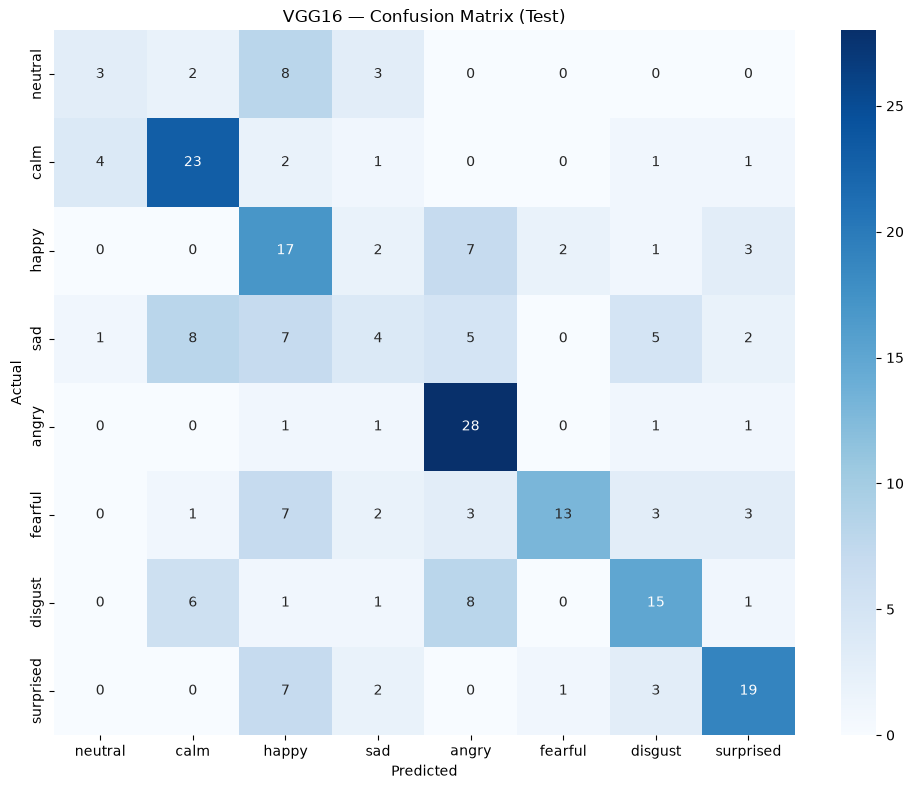

In [15]:
histories = {
    "ResNet18":    history_resnet,
    "DenseNet121": history_densenet,
    "VGG16":       history_vgg,
}

for name, model in models_dict.items():
    plot_history(histories[name], name)
    evaluate_model(model, test_loader, name)
